# Logistic Regression Model vs Random Forrest to improve performance of Cross-Asset Filer Trading Algorithm
**Project:** Cross-Asset Contradiction & Momentum Strategy  
**Asset Classes:** Equity Futures (NQ) & Cryptocurrency (BTC)  
**Timeframe:** 1-Minute Data  

### Executive Summary
This notebook tests how do ML models improve the performance of the trading algorithm using Logistic Regression and Random Forrest with Rolling Cross-Validation

### Structure:
1.  **Data Engine:** Synchronization of NQ and BTC timelines.
2.  **Strategy Engine (Naked):** Pure momentum strategy based solely on candle alignment (No filters).
3.  **Feature Engineering:** Choosing which features to include in the ML model.
4.  **Linear/Logistic Regression:** Models to improve the algorithms efficiency.
5.  **Performance Analysis:** Equity Curve Comparison, Sharpe Ratio.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import matplotlib.colors as mcolors

# --- CONFIGURATION ---
FILE_BTC = r"C:\Python\studia\ML_project\2_Phase\ENGINE_BINANCE_BTC_2024-01-01_to_2025_12_05.csv"
FILE_NQ = r"C:\Python\studia\ML_project\2_Phase\ENGINE_Nasdaq_1_minute_data_2024-01-01_to_2025-12-05.csv"

# Hard Close Time (Safety Mechanism) in UTC time
CLOSE_HOUR = 21
CLOSE_MINUTE = 55

# Settings
pd.set_option('display.max_columns', None)
print("Environment Configured.")

Environment Configured.


## 1. Data Engine
The `DataEngine` class is responsible for loading raw CSV files, standardizing column names, synchronizing timestamps (to handle different timezones), and merging the datasets into a single timeline.

In [2]:
class DataEngine:
    def __init__(self, path_btc, path_nq):
        self.path_btc = path_btc
        self.path_nq = path_nq

    def load_data(self):
        try:
            df_btc = pd.read_csv(self.path_btc, sep=None, engine='python')
            df_nq = pd.read_csv(self.path_nq, sep=None, engine='python')
        except FileNotFoundError:
            print("ERROR: Files not found.")
            return None

        def clean(df, suffix):
            # Czyszczenie nazw kolumn
            df.columns = [c.strip().lower() for c in df.columns]
            rename = {}
            for c in df.columns:
                if 'time' in c and 'utc' not in c: rename[c] = 'time'
                elif 'close' in c: rename[c] = f'close_{suffix}'
                elif 'open' in c: rename[c] = f'open_{suffix}'
                elif 'high' in c: rename[c] = f'high_{suffix}'
                elif 'low' in c: rename[c] = f'low_{suffix}'

            df = df.rename(columns=rename)

            # Obsługa czasu
            if 'time' in df.columns:
                df['time'] = df['time'].astype('int64')
                # UWAGA: Sztywne +1h. Upewnij się, że to pasuje do Twojej strefy czasowej (Zima/Lato)
                df['datetime'] = pd.to_datetime(df['time'], unit='s') + pd.Timedelta(hours=1)
            return df

        df_btc = clean(df_btc, 'btc')
        df_nq = clean(df_nq, 'nq')

        # Łączenie danych (Inner join - zostawia tylko wspólne świece)
        merged = pd.merge(df_btc, df_nq, on='datetime', how='inner', suffixes=('', '_del'))
        merged = merged.loc[:, ~merged.columns.str.endswith('_del')]
        merged.set_index('datetime', inplace=True)
        merged.sort_index(inplace=True)

        # Filtrowanie weekendów (0=Mon, 4=Fri)
        merged = merged[merged.index.dayofweek < 5]
        merged.dropna(inplace=True)

        # Obliczenia pomocnicze (do analizy, nie wpływają na logikę strategii bezpośrednio)
        merged['ret_btc'] = merged['close_btc'].pct_change()
        merged['ret_nq'] = merged['close_nq'].pct_change()
        merged['rolling_corr'] = merged['ret_btc'].rolling(60).corr(merged['ret_nq'])

        merged.dropna(inplace=True)
        print(f"Data Loaded: {len(merged)} candles.")
        return merged

# Load Data
engine = DataEngine(FILE_BTC, FILE_NQ)
market_data = engine.load_data()

Data Loaded: 677514 candles.


## 2. Naked Strategy Engine
This strategy executes trades based **only** on the directional agreement between BTC and NQ (which will be further enhanced by adding indicators)

* Hard Time Close (22:55) and Gap Protection (Risk Management is mandatory for valid backtesting).

In [3]:
import pandas_market_calendars as mcal
import pandas as pd
import numpy as np

class StrategyEngine:
    def __init__(self, data):
        self.df = data.copy()
        if 'datetime' not in self.df.columns:
            self.df = self.df.reset_index()

        print("Inicjalizacja pancernego kalendarza (Early Closes & Holidays)...")
        
        # 1. Pobieramy kalendarz NYSE (obowiązuje dla NQ)
        nyse = mcal.get_calendar('NYSE')
        schedule = nyse.schedule(start_date=self.df['datetime'].min(), 
                                 end_date=self.df['datetime'].max())
        
        # 2. Konwertujemy godziny zamknięcia na czas Twoich danych (UTC+1 / Polska)
        # mcal zwraca UTC, dodajemy 1h żeby pasowało do Twojego 'datetime' w pliku
        schedule['close_pl'] = schedule['market_close'].dt.tz_convert('UTC') + pd.Timedelta(hours=1)
        schedule['close_pl'] = schedule['close_pl'].dt.tz_localize(None) # Usuwamy info o strefie dla łatwego porównania
        
        # Tworzymy słownik {Data: Czas_Zamknięcia} dla błyskawicznego sprawdzania w pętli
        self.market_closes = schedule['close_pl'].to_dict()
        
        # 3. Pre-calculating kierunków (Sygnały)
        self.df['dir_btc'] = np.sign(self.df['close_btc'] - self.df['open_btc'])
        self.df['dir_nq'] = np.sign(self.df['close_nq'] - self.df['open_nq'])

    def run(self):
        trades = []
        position = 0
        entry_price = 0.0
        entry_time = None

        # Konwersja na listę słowników (maksymalna prędkość pętli)
        data = self.df.to_dict('records')

        for i in range(len(data) - 1):
            row = data[i]
            next_row = data[i+1] # Look-ahead bias zachowany
            curr_time = row['datetime']
            
            # --- LOGIKA ZAMYKANIA (SAFETY) ---
            day_key = curr_time.normalize()
            
            is_exit_time = False
            # A. Czy dziś jest giełda otwarta?
            if day_key not in self.market_closes:
                is_exit_time = True
            else:
                # B. Czy jesteśmy 5 min przed zamknięciem (uwzględnia Early Closes o 19:00!)
                m_close = self.market_closes[day_key]
                if curr_time >= (m_close - pd.Timedelta(minutes=5)):
                    is_exit_time = True
            
            # C. Bezpiecznik Piątkowy: 21:15 (Kluczowy na weekendy)
            if curr_time.weekday() == 4: # Piątek
                if (curr_time.hour == 21 and curr_time.minute >= 15) or curr_time.hour > 21:
                    is_exit_time = True

            # Sygnały
            dir_btc = row['dir_btc']
            dir_nq = row['dir_nq']

            # =========================================
            #           LOGIKA WYJŚCIA (EXIT)
            # =========================================
            if position != 0:
                is_divergence = (dir_btc != dir_nq)
                is_reversal = (dir_btc == -position) and (dir_nq == -position)

                if is_exit_time or is_divergence or is_reversal:
                    exit_price = row['close_nq']
                    pnl = (exit_price - entry_price) * position
                    
                    reason = "Divergence"
                    if is_exit_time: reason = "Market Close/Friday"
                    elif is_reversal: reason = "Reversal"

                    trades.append({
                        'Entry Time': entry_time,
                        'Exit Time': curr_time,
                        'Type': "LONG" if position == 1 else "SHORT",
                        'Entry Price': entry_price,
                        'Exit Price': exit_price,
                        'Points': pnl,
                        'Duration (min)': (curr_time - entry_time).total_seconds() / 60.0,
                        'Reason': reason
                    })
                    position = 0
                    if is_exit_time: continue

            # =========================================
            #           LOGIKA WEJŚCIA (ENTRY)
            # =========================================
            if position == 0 and not is_exit_time:
                # Sygnał: Zgodność BTC i NQ
                if dir_btc == 1 and dir_nq == 1:
                    position = 1
                    entry_price = next_row['open_nq'] # Look-ahead
                    entry_time = next_row['datetime']
                elif dir_btc == -1 and dir_nq == -1:
                    position = -1
                    entry_price = next_row['open_nq'] # Look-ahead
                    entry_time = next_row['datetime']

        return pd.DataFrame(trades)

## 3. Feature Engineering
### 3.1 Technical Filters
To improve the quality of signals and filter out "false positives" in noisy markets, the following classical technical indicators have been engineered:

* **EMA (Exponential Moving Average):**
    * *Purpose:* Trend Identification.
    * *Usage:* Helps filter out counter-trend trades (e.g., avoiding Longs when price is below EMA 50).
    
* **RSI (Relative Strength Index):**
    * *Purpose:* Momentum & Mean Reversion.
    * *Usage:* Identifies **Overbought (>70)** and **Oversold (<30)** conditions to prevent entering trades at the peak of a move.

* **MACD (Moving Average Convergence Divergence):**
    * *Purpose:* Trend Strength & Momentum.
    * *Usage:* Confirms the strength of the directional move using the Histogram and Signal line crossovers.

* **Bollinger Bands:**
    * *Purpose:* Volatility Analysis.
    * *Usage:* Measures market volatility and relative price levels. Helps identify "Squeeze" moments (low volatility) or breakout extensions.

In [4]:
def add_classic_indicators(df):
    """
    Dodaje klasyczne, popularne wskaźniki techniczne.
    Poprawiona wersja bez błędów zmiennych.
    """
    df = df.copy()

    # --- 1. EMA & SMA ---
    df['ema_50'] = df['close_nq'].ewm(span=50, adjust=False).mean()
    df['sma_20'] = df['close_nq'].rolling(window=20).mean()

    # --- 2. Bollinger Bands (20, 2) ---
    std_dev = df['close_nq'].rolling(window=20).std()
    df['bb_upper'] = df['sma_20'] + (std_dev * 2)
    df['bb_lower'] = df['sma_20'] - (std_dev * 2)

    # --- 3. RSI (14) ---
    delta = df['close_nq'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()

    rs = gain / loss
    df['rsi'] = 100 - (100 / (1 + rs))
    df['rsi'] = df['rsi'].fillna(50)

    # --- 4. MACD (12, 26, 9) ---
    exp12 = df['close_nq'].ewm(span=12, adjust=False).mean()
    exp26 = df['close_nq'].ewm(span=26, adjust=False).mean()

    df['macd_line'] = exp12 - exp26
    df['macd_signal'] = df['macd_line'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd_line'] - df['macd_signal']

    # --- 5. ATR (14) - POPRAWIONE ---
    # Najpierw liczymy ATR, a dopiero potem dropna, żeby nie ucinać danych dwa razy
    prev_close = df['close_nq'].shift(1)
    tr1 = df['high_nq'] - df['low_nq']
    tr2 = (df['high_nq'] - prev_close).abs()
    tr3 = (df['low_nq'] - prev_close).abs()

    df['tr'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)

    # TUTAJ BYŁ BŁĄD: Zmieniono 'window=period' na 'window=14'
    df['atr'] = df['tr'].rolling(window=14).mean()

    df['atr_pct'] = df['atr'] / df['close_nq']

    # --- CZYSZCZENIE ---
    # Dopiero teraz usuwamy wszystkie puste wiersze powstałe przez wskaźniki
    df.dropna(inplace=True)

    return df

# UŻYCIE
print("Calculating classic indicators...")
market_data = add_classic_indicators(market_data)
print(f"Features added correctly. Columns: {market_data.columns.tolist()}")

Calculating classic indicators...
Features added correctly. Columns: ['time', 'open_btc', 'high_btc', 'low_btc', 'close_btc', 'volume', 'open_nq', 'high_nq', 'low_nq', 'close_nq', 'ret_btc', 'ret_nq', 'rolling_corr', 'ema_50', 'sma_20', 'bb_upper', 'bb_lower', 'rsi', 'macd_line', 'macd_signal', 'macd_hist', 'tr', 'atr', 'atr_pct']


### 3.2 Time Feature Engine

In [5]:
def add_time_features(df):
    df = df.copy()

    # Podstawowe składniki
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute
    df['day_of_week'] = df.index.dayofweek # 0=Mon, 4=Fri

    # 1. HOUR FLOAT: Najważniejsze dla precyzyjnego filtrowania
    # Np. 14:30 zamieni się na 14.5. 21:15 na 21.25.
    # To pozwoli Ci powiedzieć: "Nie graj powyżej 20.5"
    df['time_float'] = df.index.hour + (df.index.minute / 60.0)

    # 2. SEZONY SESJI (Opcjonalne, ale super pod Regresję Logistyczną)
    # Możesz oznaczyć konkretne sesje jako "One-Hot" (0 lub 1)
    # Np. "Late NY" to czas od 19:00 do 22:00 czasu PL (zależy od Twoich danych)
    # Algorytm ML sam się nauczy, że ta kolumna ma negatywną wagę.
    df['is_eu_open'] = ((df['time_float'] >= 9.0) & (df['time_float'] < 11.0)).astype(int)
    df['is_ny_open'] = ((df['time_float'] >= 15.5) & (df['time_float'] < 17.0)).astype(int)
    df['is_late_session'] = (df['time_float'] >= 20.0).astype(int)

    return df

# APLIKACJA
market_data = add_time_features(market_data)

## 4. Data Set Generation & Labelling for Logistic Regression Model

In [6]:
# --- CELL: DATASET GENERATION (ENHANCED: DIV + REVERSAL EXIT) ---
import pandas as pd
import numpy as np

# Konfiguracja
SAFETY_CLOSE_HOUR = 21
SAFETY_CLOSE_MINUTE = 55

def get_trade_outcome_enhanced(entry_idx, df, entry_direction):
    """
    Symulacja z ulepszonym wyjściem (Enhanced Exit).
    Zamykamy pozycję w 3 przypadkach:
    1. EOD (Time) - Koniec dnia.
    2. Divergence - Sygnały się rozjeżdżają (jeden rośnie, drugi spada).
    3. Reversal (NOWOŚĆ) - Oba sygnały idą PRZECIWKO naszej pozycji.
    """
    entry_price = df.iloc[entry_idx]['open_nq']

    # Symulacja do max 600 minut (zakładamy sesję intraday)
    subset = df.iloc[entry_idx : entry_idx + 600]

    for i, row in subset.iterrows():
        current_idx = i
        curr_time = row['datetime']

        # --- 1. WARUNEK EOD ---
        is_eod = (curr_time.hour == SAFETY_CLOSE_HOUR and curr_time.minute >= SAFETY_CLOSE_MINUTE) or \
                 (curr_time.hour > SAFETY_CLOSE_HOUR)

        # --- Analiza kierunku świecy ---
        curr_dir_btc = np.sign(row['close_btc'] - row['open_btc'])
        curr_dir_nq = np.sign(row['close_nq'] - row['open_nq'])

        # --- 2. WARUNEK DYWERGENCJI (Rozjazd) ---
        # BTC i NQ idą w różne strony
        is_divergence = (curr_dir_btc != curr_dir_nq)

        # --- 3. WARUNEK REVERSAL (Odwrócenie) ---
        # Jeśli mamy Longa (1), a oba rynki spadają (-1) -> UCIEKAJ!
        # Jeśli mamy Shorta (-1), a oba rynki rosną (1) -> UCIEKAJ!
        # To chroni przed trzymaniem pozycji, gdy cały rynek krwawi.
        is_reversal = (curr_dir_btc == -entry_direction) and (curr_dir_nq == -entry_direction)

        # WYJŚCIE
        if is_eod or is_divergence or is_reversal:
            return (row['close_nq'] - entry_price) * entry_direction, current_idx

    # Fallback
    return (subset.iloc[-1]['close_nq'] - entry_price) * entry_direction, subset.index[-1]

def generate_labeled_dataset_enhanced(df):
    print("Generating candidates with ENHANCED logic (Div + Reversal)...")
    candidates = []
    df_reset = df.reset_index()

    for i in range(1, len(df_reset) - 605):
        row = df_reset.iloc[i]

        # Sygnał wejścia
        dir_btc = np.sign(row['close_btc'] - row['open_btc'])
        dir_nq = np.sign(row['close_nq'] - row['open_nq'])

        if dir_btc == dir_nq and dir_btc != 0:

            # Używamy nowej funkcji z Reversalem
            pnl, exit_idx = get_trade_outcome_enhanced(i+1, df_reset, dir_btc)

            candidates.append({
                'entry_idx': i+1,
                'exit_idx': exit_idx,
                'datetime': df_reset.iloc[i+1]['datetime'],
                'pnl': pnl,
                'target': 1 if pnl > 0 else 0,

                # Cechy (X)
                'rsi': row['rsi'],
                'atr_pct': row['atr_pct'],
                'hour': row['hour'],
                'macd_hist': row['macd_hist'],
                'bb_width': (row['bb_upper'] - row['bb_lower']) / row['sma_20'],
                'dist_from_ema': (row['close_nq'] - row['ema_50']) / row['ema_50']
            })

    return pd.DataFrame(candidates)

# GENEROWANIE
ml_dataset = generate_labeled_dataset_enhanced(market_data)
ml_dataset = pd.get_dummies(ml_dataset, columns=['hour'], prefix='hour')

print(f"Dataset Ready. Candidates: {len(ml_dataset)}")
print(f"Total PnL (Vector Sum): {ml_dataset['pnl'].sum():.2f}")

Generating candidates with ENHANCED logic (Div + Reversal)...
Dataset Ready. Candidates: 389174
Total PnL (Vector Sum): 18367.35


In [7]:
# --- NOWY CELL: CHRONOLOGICZNY SPLIT DANYCH (80% Optymalizacja / 20% Test Prawdy) ---

# Obliczamy punkt podziału
split_idx = int(len(ml_dataset) * 0.80)

# Tworzymy dwa osobne zbiory (ważne: bez shuffle, zachowujemy kolejność czasu!)
train_val_set = ml_dataset.iloc[:split_idx].copy()
final_test_set = ml_dataset.iloc[split_idx:].copy()

print(f"✅ Dane podzielone!")
print(f"📊 Zbiór do Grid Search (Train+Val): {len(train_val_set)} rekordów")
print(f"📊 Zbiór do Finałowego Testu (Unseen): {len(final_test_set)} rekordów")
print(f"🕒 Okres testowy zaczyna się od: {final_test_set['datetime'].min()}")

✅ Dane podzielone!
📊 Zbiór do Grid Search (Train+Val): 311339 rekordów
📊 Zbiór do Finałowego Testu (Unseen): 77835 rekordów
🕒 Okres testowy zaczyna się od: 2025-07-23 05:43:00


## 5. Rolling Cross-Validation


--- STARTING OPTIMIZED WALK-FORWARD ANALYSIS ---
Window 0: Best Threshold=0.51 | ML PnL=54.3
Window 5000: Best Threshold=0.55 | ML PnL=7.3
Window 10000: Best Threshold=0.50 | ML PnL=220.5
Window 15000: Best Threshold=0.51 | ML PnL=36.2
Window 20000: Best Threshold=0.51 | ML PnL=155.1
Window 25000: Best Threshold=0.57 | ML PnL=163.3
Window 30000: Best Threshold=0.51 | ML PnL=-14.1
Window 35000: Best Threshold=0.52 | ML PnL=40.4
Window 40000: Best Threshold=0.58 | ML PnL=-27.6
Window 45000: Best Threshold=0.50 | ML PnL=52.4
Window 50000: Best Threshold=0.52 | ML PnL=-13.4
Window 55000: Best Threshold=0.50 | ML PnL=-137.6
Window 60000: Best Threshold=0.51 | ML PnL=-303.7
Window 65000: Best Threshold=0.53 | ML PnL=-187.1
Window 70000: Best Threshold=0.53 | ML PnL=64.0
Window 75000: Best Threshold=0.50 | ML PnL=29.4
Window 80000: Best Threshold=0.50 | ML PnL=68.1
Window 85000: Best Threshold=0.50 | ML PnL=-62.6
Window 90000: Best Threshold=0.52 | ML PnL=14.5
Window 95000: Best Threshold=0.

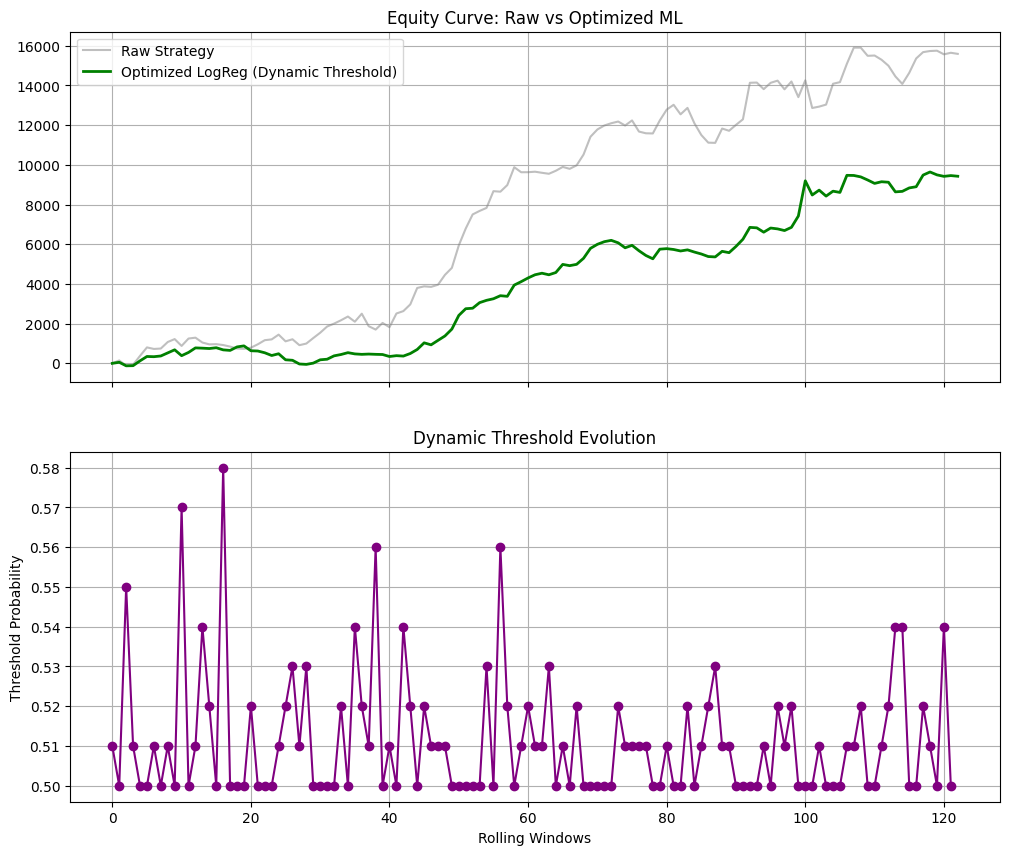

Final Raw: 15593.37
Final ML:  9427.26


In [8]:
# --- CELL: OPTIMIZED ROLLING CV (THRESHOLD TUNING) ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def optimize_threshold_on_train(model, X_train_scaled, df_train):
    """
    Szuka progu (threshold), który dałby największy zysk na danych TRENINGOWYCH.
    Dzięki temu uczymy się "charakterystyki modelu", nie patrząc w przyszłość.
    """
    best_threshold = 0.5
    best_pnl = -np.inf

    # Pobieramy prawdopodobieństwa dla zbioru treningowego
    probs_train = model.predict_proba(X_train_scaled)[:, 1]

    # Testujemy progi od 0.50 do 0.70 co 0.01
    thresholds = np.arange(0.50, 0.70, 0.01)

    for thr in thresholds:
        # Symulacja wyniku na zbiorze Train dla danego progu
        # (Uproszczona wektorowa symulacja dla szybkości - PnL sumaryczny)
        # Bierzemy tylko te trady, gdzie prob > thr
        mask = probs_train > thr
        pnl_sum = df_train.loc[mask, 'pnl'].sum()

        # Opcjonalnie: Dodajemy warunek minimalnej liczby tradów (żeby nie wybrał 1 tradu z gigantycznym zyskiem)
        n_trades = mask.sum()
        if n_trades > 10 and pnl_sum > best_pnl:
            best_pnl = pnl_sum
            best_threshold = thr

    return best_threshold

def run_rolling_cv_optimized(df, train_window=4000, step=2500):
    print("\n--- STARTING OPTIMIZED WALK-FORWARD ANALYSIS ---")

    # Cechy (X)
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    # Model: Dodajemy C=0.1 (lekka regularyzacja, żeby nie przeuczyć)
    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
    scaler = StandardScaler()

    equity_curve_ml = [0]
    equity_curve_raw = [0]
    threshold_history = [] # Do analizy, jak zmieniał się próg w czasie

    # Pętla Walk-Forward
    for start in range(0, len(df) - train_window - step, step):
        # 1. Podział
        train_df = df.iloc[start : start + train_window].reset_index(drop=True)
        test_df = df.iloc[start + train_window : start + train_window + step].reset_index(drop=True)

        X_train = train_df[features]
        y_train = train_df['target']
        X_test = test_df[features]

        # 2. Skalowanie
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 3. Trening
        model.fit(X_train_scaled, y_train)

        # 4. --- OPTYMALIZACJA PROGU (NA ZBIORZE TRENINGOWYM!) ---
        # Pytamy: "Jaki próg działał najlepiej w przeszłości?"
        best_thr = optimize_threshold_on_train(model, X_train_scaled, train_df)
        threshold_history.append(best_thr)

        # 5. Predykcja na teście z użyciem zoptymalizowanego progu
        probs_test = model.predict_proba(X_test_scaled)[:, 1]

        # 6. Symulacja Handlu (No Overlap)
        last_exit_ml = -1
        pnl_period_ml = 0
        last_exit_raw = -1
        pnl_period_raw = 0

        for i in range(len(test_df)):
            row = test_df.iloc[i]
            entry_idx = row['entry_idx']
            prob = probs_test[i]

            # ML Strategy (używamy best_thr zamiast 0.55)
            if entry_idx > last_exit_ml:
                if prob > best_thr:
                    pnl_period_ml += row['pnl']
                    last_exit_ml = row['exit_idx']

            # Raw Strategy
            if entry_idx > last_exit_raw:
                pnl_period_raw += row['pnl']
                last_exit_raw = row['exit_idx']

        equity_curve_ml.append(equity_curve_ml[-1] + pnl_period_ml)
        equity_curve_raw.append(equity_curve_raw[-1] + pnl_period_raw)

        if start % 1000 == 0:
            print(f"Window {start}: Best Threshold={best_thr:.2f} | ML PnL={pnl_period_ml:.1f}")

    return equity_curve_raw, equity_curve_ml, threshold_history

# URUCHOMIENIE
if not train_val_set.empty:
    eq_raw, eq_ml, thr_hist = run_rolling_cv_optimized(train_val_set)

    # WYKRESY
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Wykres 1: Equity Curve
    ax1.plot(eq_raw, label='Raw Strategy', color='gray', alpha=0.5)
    ax1.plot(eq_ml, label='Optimized LogReg (Dynamic Threshold)', color='green', linewidth=2)
    ax1.set_title('Equity Curve: Raw vs Optimized ML')
    ax1.legend()
    ax1.grid(True)

    # Wykres 2: Jak zmieniał się próg w czasie?
    ax2.plot(thr_hist, marker='o', linestyle='-', color='purple')
    ax2.set_title('Dynamic Threshold Evolution')
    ax2.set_ylabel('Threshold Probability')
    ax2.set_xlabel('Rolling Windows')
    ax2.grid(True)

    plt.show()

    print(f"Final Raw: {eq_raw[-1]:.2f}")
    print(f"Final ML:  {eq_ml[-1]:.2f}")
else:
    print("No data.")

## 6. Performance Metric Analysis

### 6.1 Performance Dashboard

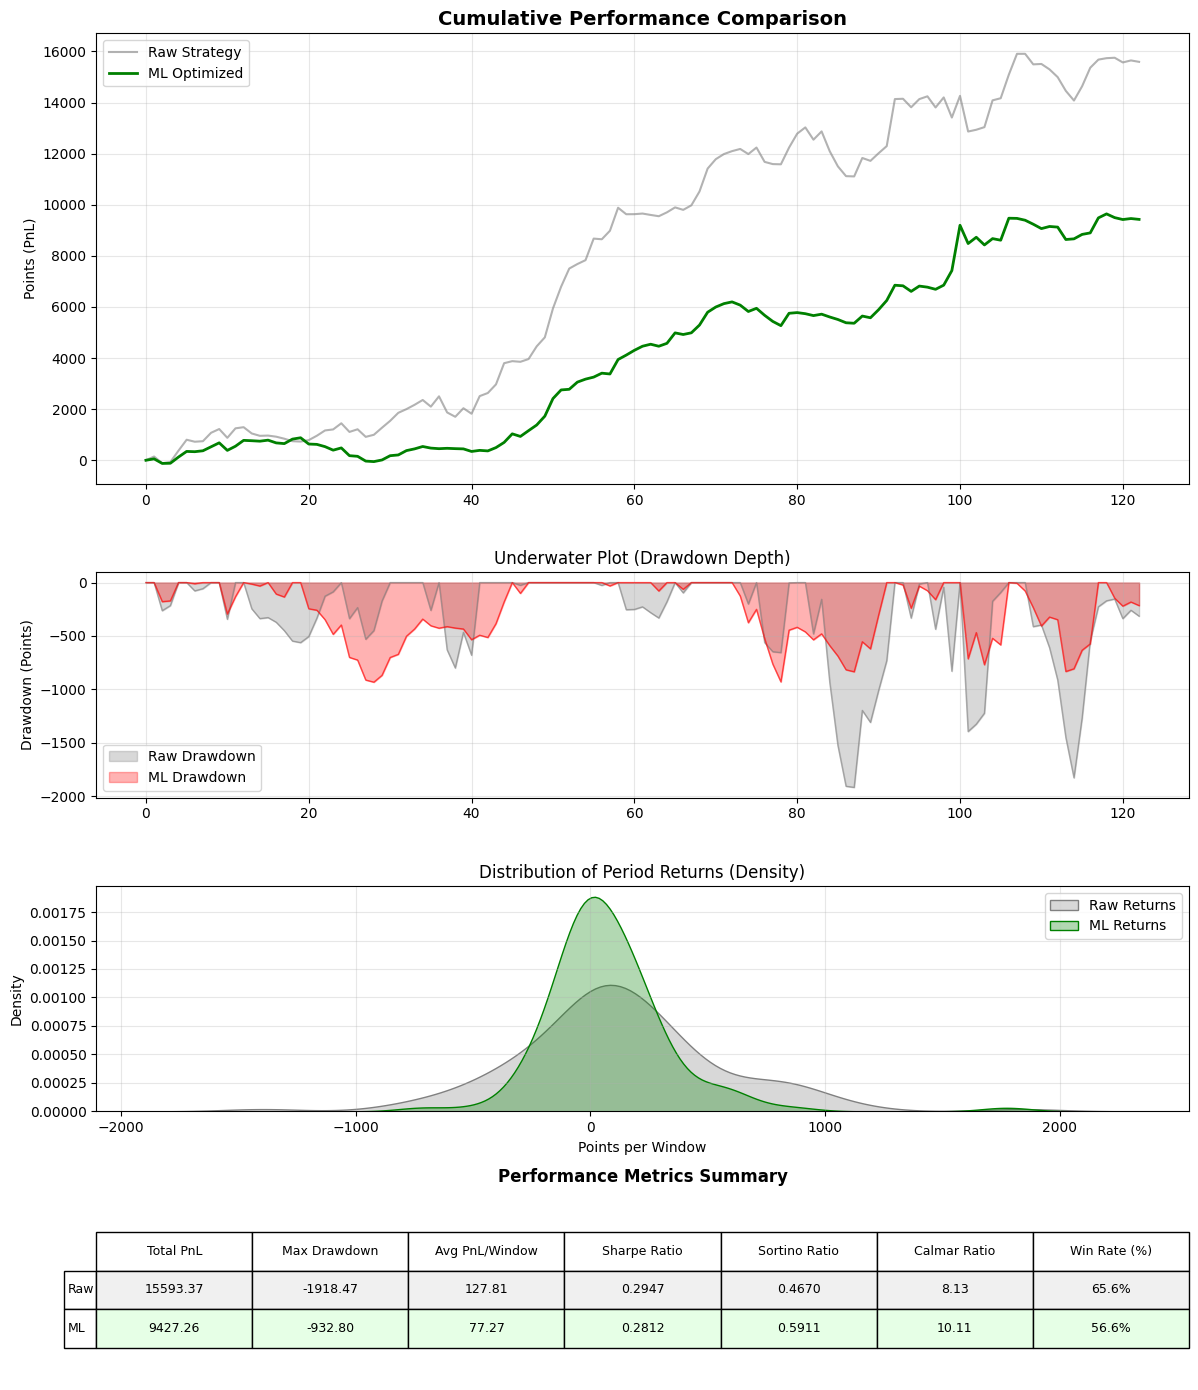

In [9]:
# --- CELL 1: ROBUST PERFORMANCE DASHBOARD (FULL VERSION) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_drawdown_series(equity_curve):
    """Oblicza serię drawdownów (obsunięć) w punktach."""
    series = pd.Series(equity_curve)
    running_max = series.cummax()
    drawdown = series - running_max
    return drawdown

def calculate_robust_metrics(equity_curve):
    equity = pd.Series(equity_curve)
    returns = equity.diff().dropna()

    total_pnl = equity.iloc[-1] - equity.iloc[0]
    avg_trade = returns.mean()

    dd_series = calculate_drawdown_series(equity)
    max_dd = dd_series.min()

    std_dev = returns.std()
    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() if len(downside_returns) > 0 else 1.0

    sharpe = (returns.mean() / std_dev) if std_dev != 0 else 0
    sortino = (returns.mean() / downside_std) if downside_std != 0 else 0
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0
    win_rate = (returns > 0).mean() * 100

    return {
        "Total PnL": f"{total_pnl:.2f}",
        "Max Drawdown": f"{max_dd:.2f}",
        "Avg PnL/Window": f"{avg_trade:.2f}",
        "Sharpe Ratio": f"{sharpe:.4f}",
        "Sortino Ratio": f"{sortino:.4f}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Win Rate (%)": f"{win_rate:.1f}%"
    }

def plot_performance_dashboard(eq_raw, eq_ml):
    # Obliczamy zwroty lokalnie dla histogramu
    returns_raw = pd.Series(eq_raw).diff().dropna()
    returns_ml = pd.Series(eq_ml).diff().dropna()

    # Setup Grid (4 wiersze: Equity, Drawdown, Histogram, Tabela)
    fig = plt.figure(figsize=(12, 14))
    gs = fig.add_gridspec(4, 1, height_ratios=[2, 1, 1, 0.8])

    # 1. EQUITY CURVE
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(eq_raw, label='Raw Strategy', color='gray', alpha=0.6)
    ax1.plot(eq_ml, label='ML Optimized', color='green', linewidth=2)
    ax1.set_title('Cumulative Performance Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Points (PnL)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # 2. DRAWDOWN
    dd_raw = calculate_drawdown_series(eq_raw)
    dd_ml = calculate_drawdown_series(eq_ml)

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.fill_between(range(len(dd_raw)), dd_raw, 0, color='gray', alpha=0.3, label='Raw Drawdown')
    ax2.plot(dd_raw, color='gray', alpha=0.6, linewidth=1)

    ax2.fill_between(range(len(dd_ml)), dd_ml, 0, color='red', alpha=0.3, label='ML Drawdown')
    ax2.plot(dd_ml, color='red', alpha=0.6, linewidth=1)

    ax2.set_title('Underwater Plot (Drawdown Depth)', fontsize=12)
    ax2.set_ylabel('Drawdown (Points)')
    ax2.legend(loc='lower left')
    ax2.grid(True, alpha=0.3)

    # 3. HISTOGRAM ZWROTÓW (Distribution of Returns)
    ax3 = fig.add_subplot(gs[2])
    sns.kdeplot(returns_raw, ax=ax3, label='Raw Returns', color='gray', fill=True, alpha=0.3)
    sns.kdeplot(returns_ml, ax=ax3, label='ML Returns', color='green', fill=True, alpha=0.3)
    ax3.set_title('Distribution of Period Returns (Density)', fontsize=12)
    ax3.set_xlabel('Points per Window')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. METRICS TABLE
    m_raw = calculate_robust_metrics(eq_raw)
    m_ml = calculate_robust_metrics(eq_ml)

    ax4 = fig.add_subplot(gs[3])
    ax4.axis('off')
    col_labels = list(m_raw.keys())
    cell_text = [
        [f"{v}" for v in m_raw.values()],
        [f"{v}" for v in m_ml.values()]
    ]

    # Kolorowanie tabeli
    colors = [['#f0f0f0']*len(col_labels), ['#e6ffe6']*len(col_labels)]

    table = ax4.table(cellText=cell_text, colLabels=col_labels,
                      rowLabels=['Raw', 'ML'],
                      cellColours=colors,
                      loc='center', cellLoc='center')
    table.scale(1, 2)
    table.set_fontsize(12)
    ax4.set_title('Performance Metrics Summary', y=1.05, fontweight='bold')

    plt.tight_layout()
    plt.show()

# URUCHOMIENIE
if 'eq_raw' in locals() and 'eq_ml' in locals():
    plot_performance_dashboard(eq_raw, eq_ml)
else:
    print("Brak danych eq_raw/eq_ml.")

### 6.2 Time of the Day Analysis

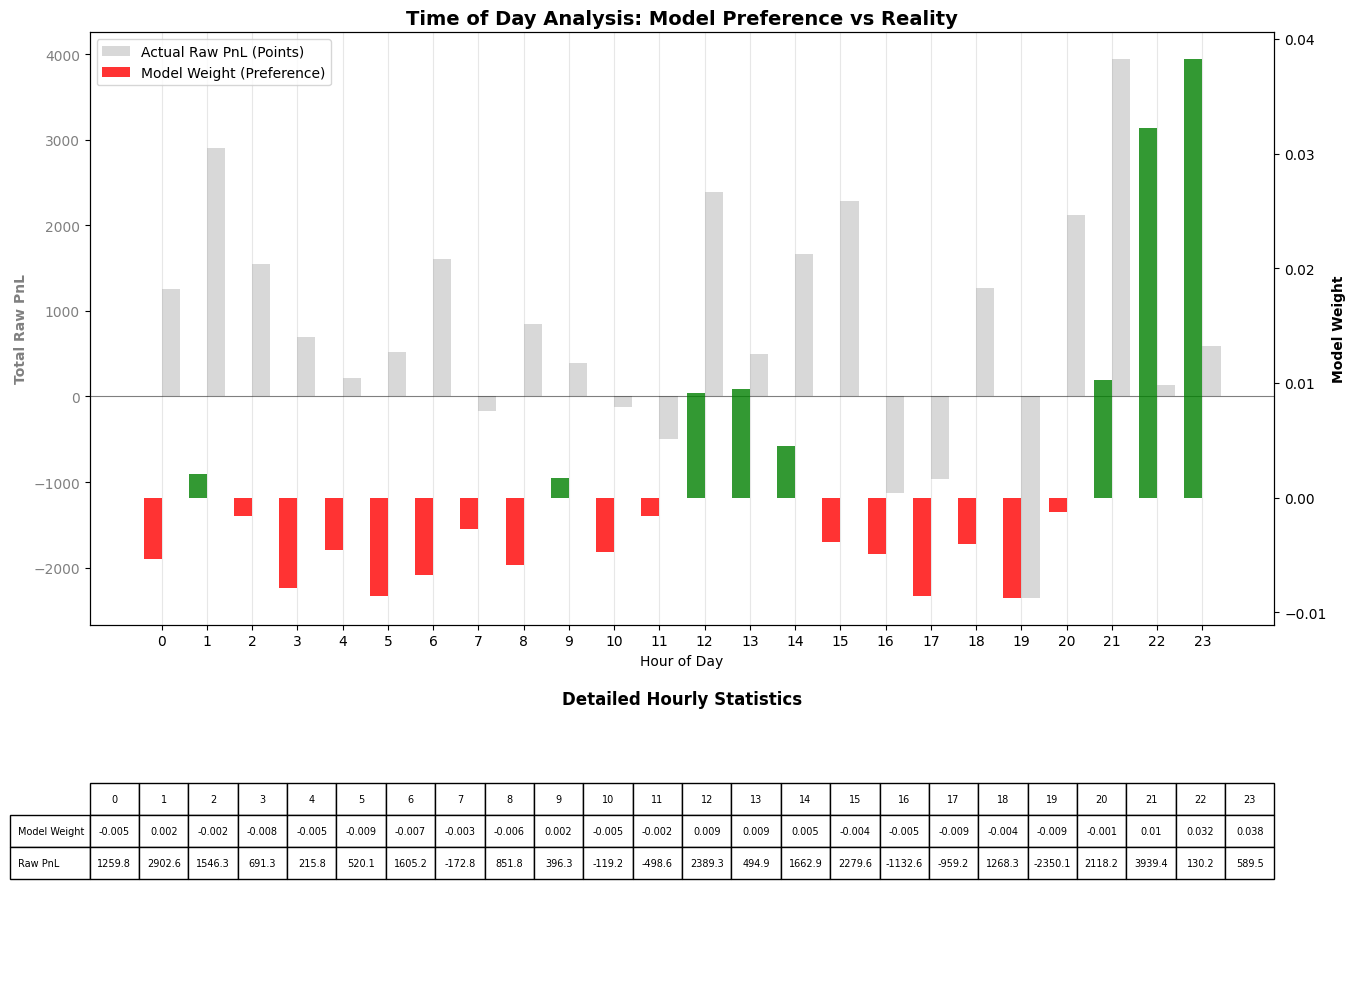

In [10]:
# --- CELL 2: TIME OF DAY ANALYSIS (CHART + TABLE) ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def analyze_hourly_bias(df):
    """Analizuje wagi modelu i rzeczywisty PnL dla godzin."""
    features = [c for c in df.columns if c not in ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']]
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features])
    y = df['target']

    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)
    model.fit(X, y)

    coefs = []
    hours = []

    # Odtwarzamy prawdziwą godzinę
    df['real_hour'] = df['datetime'].dt.hour
    raw_pnl_by_hour = df.groupby('real_hour')['pnl'].sum()

    for col in features:
        if col.startswith('hour_'):
            h = int(col.split('_')[1])
            idx = features.index(col)
            weight = model.coef_[0][idx]
            hours.append(h)
            coefs.append(weight)

    res = pd.DataFrame({'Hour': hours, 'Model Weight': coefs})
    res = res.sort_values('Hour')
    res['Raw PnL'] = res['Hour'].map(raw_pnl_by_hour).fillna(0)

    return res

def plot_hourly_analysis_detailed(dataset):
    # Analiza danych
    hour_stats = analyze_hourly_bias(dataset)

    # Setup Wykresu (Wykres na górze, tabela na dole)
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1]) # Wykres 2x wyższy niż tabela

    # --- 1. WYKRES (DUAL AXIS) ---
    ax1 = fig.add_subplot(gs[0])
    width = 0.4
    x = hour_stats['Hour']

    # Oś lewa (PnL - Szare)
    bars_pnl = ax1.bar(x + width/2, hour_stats['Raw PnL'], width, label='Actual Raw PnL (Points)', color='gray', alpha=0.3)
    ax1.set_ylabel('Total Raw PnL', color='gray', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='gray')
    ax1.axhline(0, color='black', linewidth=0.8, alpha=0.5)

    # Oś prawa (Wagi - Kolorowe)
    ax2 = ax1.twinx()
    colors = ['green' if w > 0 else 'red' for w in hour_stats['Model Weight']]
    bars_w = ax2.bar(x - width/2, hour_stats['Model Weight'], width, label='Model Weight (Preference)', color=colors, alpha=0.8)
    ax2.set_ylabel('Model Weight', color='black', fontweight='bold')

    # Oś X
    ax1.set_xlabel('Hour of Day')
    ax1.set_xticks(x)
    ax1.set_title('Time of Day Analysis: Model Preference vs Reality', fontsize=14, fontweight='bold')

    # --- POPRAWIONA LEGENDA (Łączona) ---
    # Pobieramy uchwyty (handles) i etykiety z obu osi
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # Rysujemy jedną legendę na osi ax1
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    ax1.grid(True, axis='x', alpha=0.3)

    # --- 2. TABELA DANYCH ---
    ax_table = fig.add_subplot(gs[1])
    ax_table.axis('off')

    # Formatowanie danych do tabeli
    table_data = hour_stats.copy()
    table_data['Raw PnL'] = table_data['Raw PnL'].round(1)
    table_data['Model Weight'] = table_data['Model Weight'].round(3)

    # Transpozycja, żeby godziny były nagłówkami (czytelniej dla długiego szeregu)
    # Wybieramy tylko godziny, które mają dane
    table_data = table_data.set_index('Hour').T

    the_table = ax_table.table(cellText=table_data.values,
                               rowLabels=table_data.index,
                               colLabels=table_data.columns,
                               loc='center', cellLoc='center')

    the_table.scale(1, 1.5)
    the_table.set_fontsize(10)
    ax_table.set_title("Detailed Hourly Statistics", y=0.9, fontweight='bold')

    plt.tight_layout()
    plt.show()

# URUCHOMIENIE
if 'train_val_set' in locals():
    plot_hourly_analysis_detailed(train_val_set)
else:
    print("Brak train_val_set.")

## 7. Grid Search for Cross Validation Optimization

🚀 Rozpoczynam Grid Search...


Grid Scanning:   0%|          | 0/18 [00:00<?, ?cfg/s]


✅ Done. Best Sharpe: 0.2640
🏆 WINNER: Window=5000, Step=1000


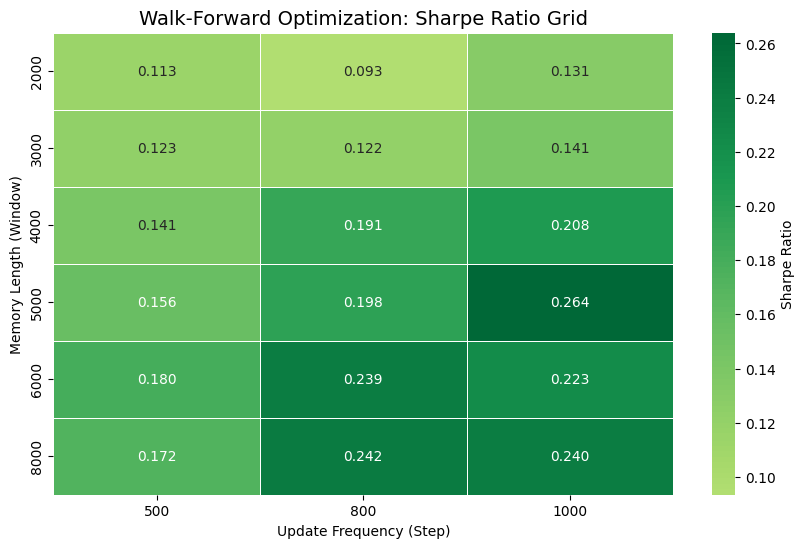

In [17]:
# --- CELL: GRID SEARCH (REPAIRED & SILENCED) ---
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

# 1. DEFINICJA BRAKUJĄCEJ FUNKCJI (Musisz ją mieć tutaj)
def calculate_quick_sharpe(equity_curve):
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    if len(returns) < 2 or returns.std() == 0:
        return 0.0
    return returns.mean() / returns.std()

# Klasa do wyciszania printów z wnętrza innych funkcji
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

def run_grid_search_windows(df):
    print("🚀 Rozpoczynam Grid Search...")
    
    # PARAMETRY
    windows = [2000, 3000, 4000, 5000, 6000, 8000]
    steps = [500, 800, 1000]
    
    combos = [(w, s) for w in windows for s in steps if s < w]
    
    results = []
    # Używamy leave=True, żeby pasek został po zakończeniu
    pbar = tqdm(combos, desc="Grid Scanning", unit="cfg", leave=True)
    
    for w, s in pbar:
        pbar.set_postfix({"win": w, "stp": s})
        try:
            # Używamy context managera, żeby wyciszyć te setki linii "Window 1000..."
            with HiddenPrints():
                # Tutaj zakładam, że ta funkcja zwraca 3 argumenty: (stats, equity, models)
                _, eq_ml, _ = run_rolling_cv_optimized(df, train_window=w, step=s)
            
            # Obliczamy Sharpe
            sr = calculate_quick_sharpe(eq_ml)
            results.append({'Window': w, 'Step': s, 'Sharpe': sr})
            
        except Exception as e:
            # Ten print się pokaże, bo jest poza HiddenPrints
            # Używamy pbar.write zamiast print, żeby nie psuć paska
            pbar.write(f"⚠️ Error for W={w}, S={s}: {e}")
            continue

    # 2. PRZYGOTOWANIE WYNIKÓW
    res_df = pd.DataFrame(results)
    if res_df.empty:
        print("❌ Brak wyników do wyświetlenia. Sprawdź funkcję run_rolling_cv_optimized.")
        return

    best_sr = res_df['Sharpe'].max()
    print(f"\n✅ Done. Best Sharpe: {best_sr:.4f}")
    
    # Wyświetlenie najlepszej konfiguracji
    best_row = res_df.loc[res_df['Sharpe'].idxmax()]
    print(f"🏆 WINNER: Window={int(best_row['Window'])}, Step={int(best_row['Step'])}")

    # 3. WYKRES
    pivot = res_df.pivot(index='Window', columns='Step', values='Sharpe')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap='RdYlGn', center=0, 
                linewidths=.5, cbar_kws={'label': 'Sharpe Ratio'})
    
    plt.title('Walk-Forward Optimization: Sharpe Ratio Grid', fontsize=14)
    plt.ylabel('Memory Length (Window)')
    plt.xlabel('Update Frequency (Step)')
    plt.show()

# URUCHOMIENIE
if 'train_val_set' in locals():
    run_grid_search_windows(train_val_set)
else:
    print("Brak zmiennej train_val_set!")

🚀 Running Experiment: Window=5000, Step=1000...
(Proszę czekać, obliczenia w tle - logi wyciszone dla czytelności...)
✅ Obliczenia zakończone.

=== 📊 RETURN DISTRIBUTION STATISTICS ===
Mean Return:      43.1080
Std Dev:          163.3084
Skewness:         1.3837
Kurtosis:         3.8269
------------------------------
✅ Positive Skewness: Dobrze! Strategia ucina straty i pozwala zyskom rosnąć (ogon w prawo).
⚠️ High Kurtosis (Fat Tails): Występują ekstremalne wyniki częściej niż w rozkładzie normalnym.

--- PERFORMANCE DASHBOARD ---


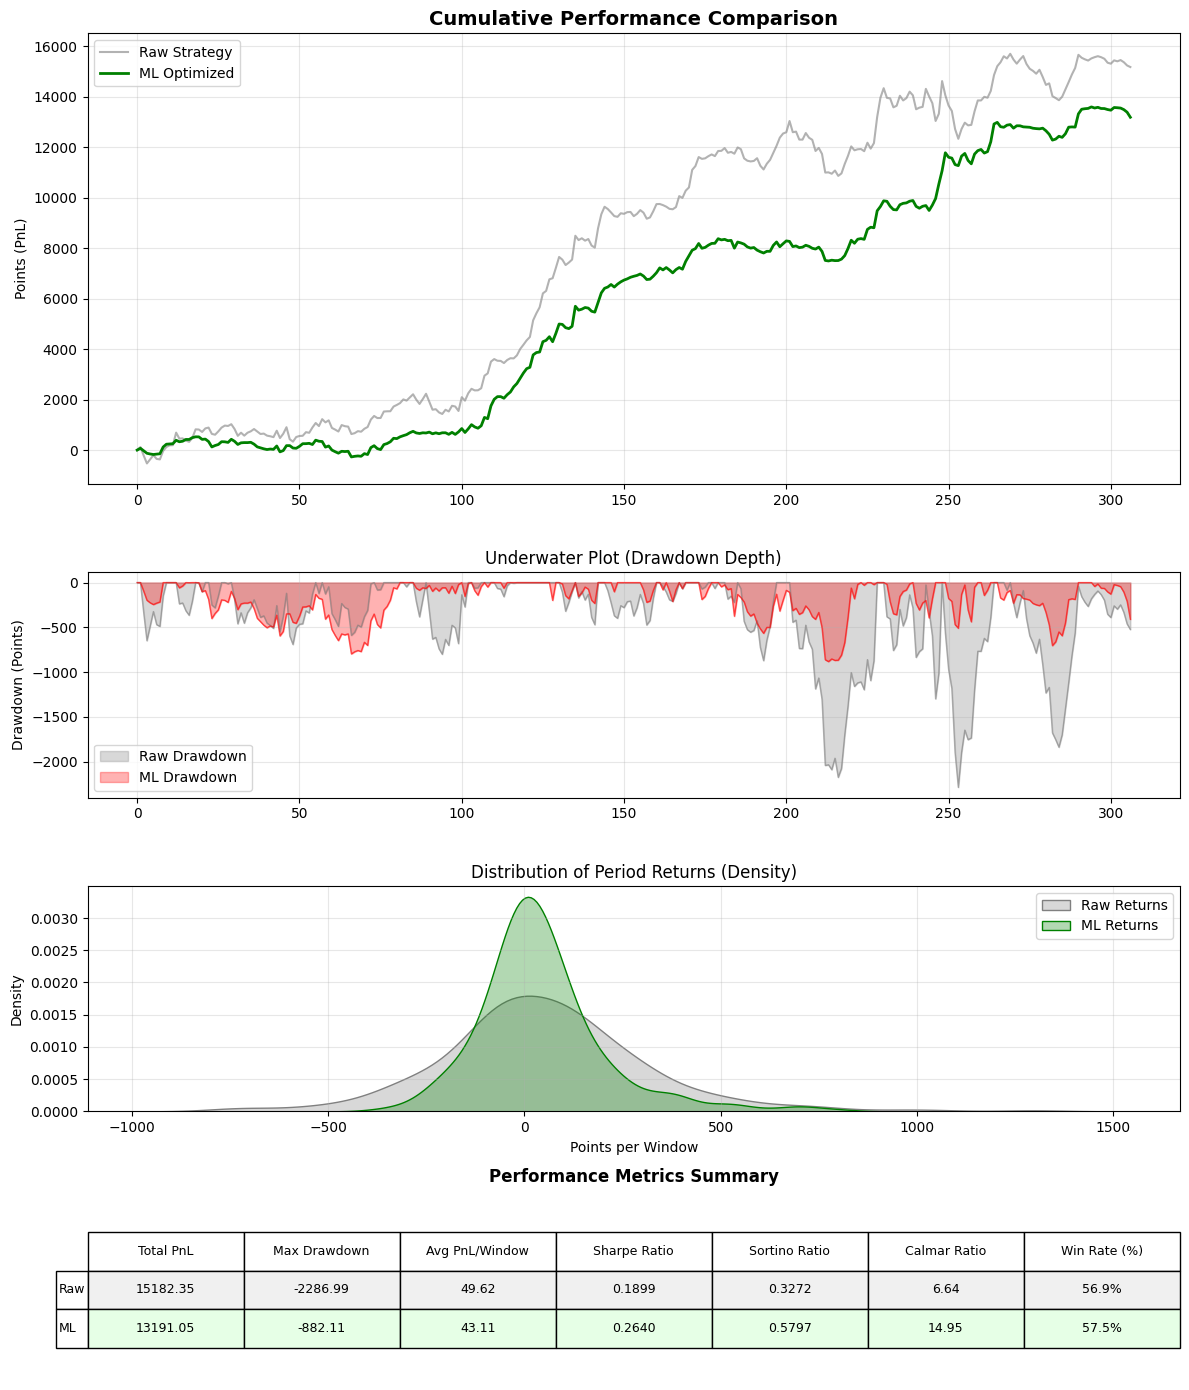


--- TIME OF DAY ANALYSIS ---


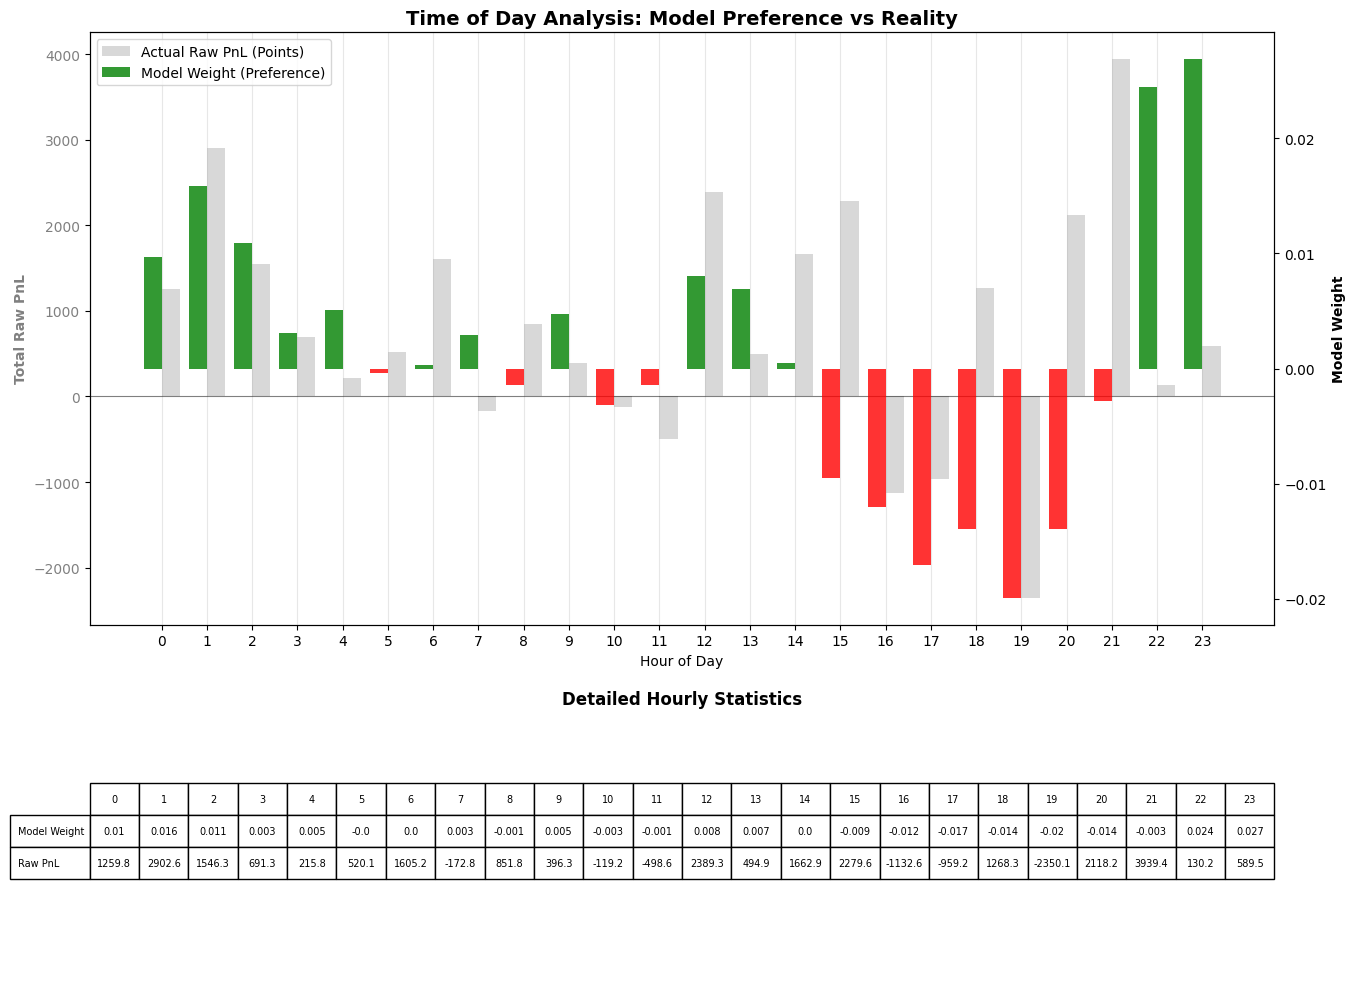

In [23]:
# --- CELL: EXPERIMENT (SILENT MODE) + DISTRIBUTION ANALYSIS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import sys
import os

# Klasa do wyciszania printów (jeśli nie zdefiniowałeś jej wcześniej)
class HiddenPrints:
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

# 1. Konfiguracja Eksperymentalna
EXPERIMENTAL_WINDOW = 5000
EXPERIMENTAL_STEP = 1000

print(f"🚀 Running Experiment: Window={EXPERIMENTAL_WINDOW}, Step={EXPERIMENTAL_STEP}...")
print("(Proszę czekać, obliczenia w tle - logi wyciszone dla czytelności...)")

# 2. Symulacja (Wyciszona)
with HiddenPrints():
    eq_raw_exp, eq_ml_experimental, _ = run_rolling_cv_optimized(
        train_val_set, 
        train_window=EXPERIMENTAL_WINDOW, 
        step=EXPERIMENTAL_STEP
    )

print("✅ Obliczenia zakończone.")

# Aktualizacja zmiennych
eq_raw = eq_raw_exp 
eq_ml = eq_ml_experimental

# 3. Analiza Dystrybucji Zwrotów (Statystyka)
# Obliczamy zwroty (zmiana kapitału krok po kroku)
returns = pd.Series(eq_ml).diff().dropna()

print("\n=== 📊 RETURN DISTRIBUTION STATISTICS ===")
print(f"Mean Return:      {returns.mean():.4f}")
print(f"Std Dev:          {returns.std():.4f}")
print(f"Skewness:         {returns.skew():.4f}")
print(f"Kurtosis:         {returns.kurtosis():.4f}")
print("-" * 30)

# Interpretacja Skewness
if returns.skew() > 0:
    print("✅ Positive Skewness: Dobrze! Strategia ucina straty i pozwala zyskom rosnąć (ogon w prawo).")
elif returns.skew() < -0.5:
    print("⚠️ Negative Skewness: Uwaga! Ryzyko rzadkich, ale głębokich strat (ogon w lewo).")
else:
    print("ℹ️ Neutral Skewness: Rozkład zbliżony do symetrycznego.")

# Interpretacja Kurtosis
if returns.kurtosis() > 3:
    print("⚠️ High Kurtosis (Fat Tails): Występują ekstremalne wyniki częściej niż w rozkładzie normalnym.")
else:
    print("✅ Low Kurtosis: Wyniki są stabilne, brak szalonych wyskoków.")
print("=" * 30)

# 4. Wyświetlenie Dashboardów
print("\n--- PERFORMANCE DASHBOARD ---")
if 'plot_performance_dashboard' in locals():
    plot_performance_dashboard(eq_raw, eq_ml)

print("\n--- TIME OF DAY ANALYSIS ---")
if 'plot_hourly_analysis_detailed' in locals():
    # Upewniamy się, że funkcja dostanie df z wynikami, jeśli tego wymaga
    # Jeśli plot_hourly... bierze surowe dane, to zostawiamy train_val_set
    plot_hourly_analysis_detailed(train_val_set)

Running Simulation... Window=5000, Step=1000

>>> REPORT: ORIGINAL (24H STRATEGY) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 12840.63
Max Drawdown         | -1136.65
Sharpe Ratio         | 0.0162
Sortino Ratio        | 0.0248
Calmar Ratio         | 11.30
Win Rate             | 42.89%
Active Trades        | 93884

>>> REPORT: FILTERED (NO NY SESSION) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 6732.16
Max Drawdown         | -504.88
Sharpe Ratio         | 0.0161
Sortino Ratio        | 0.0194
Calmar Ratio         | 13.33
Win Rate             | 43.05%
Active Trades        | 53479

>>> REPORT: REJECTED (NY SESSION ONLY) <<<
Metric               | Value          
-----------------------------------
Total PnL            | 6108.47
Max Drawdown         | -1312.86
Sharpe Ratio         | 0.0091
Sortino Ratio        | 0.0093
Calmar Ratio         | 4.65
Win Rate             | 42.68%


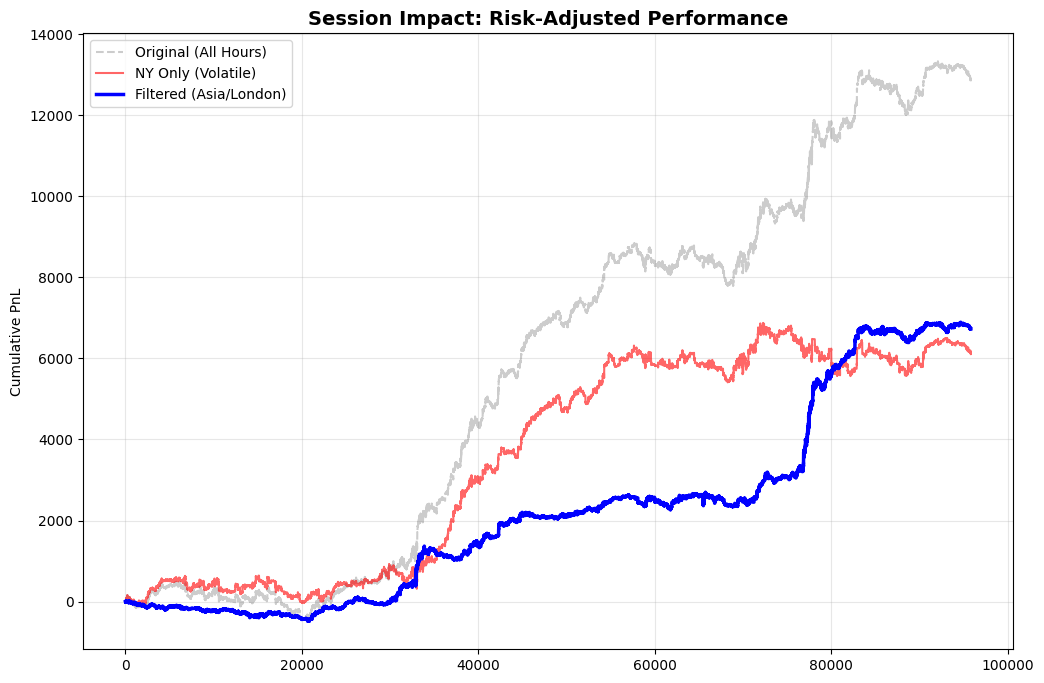


ℹ️ INFO: Oryginalna strategia ma wyższe Sharpe Ratio. Zmienność NY popłaca.


In [26]:
# --- CELL: ADVANCED SESSION ANALYSIS WITH RISK METRICS (SHARPE & DD) ---
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. KONFIGURACJA (Wymuszamy parametry eksperymentalne)
ANALYSIS_WINDOW = 5000
ANALYSIS_STEP = 1000
EXCLUDED_HOURS_NY = list(range(13, 23)) # NY Session Exclusion

def get_risk_metrics(equity_curve):
    """Oblicza zaawansowane metryki ryzyka."""
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    active_returns = returns[returns != 0] # Tylko aktywne okresy

    # Podstawy
    total_pnl = series.iloc[-1] - series.iloc[0]

    # Drawdown
    running_max = series.cummax()
    drawdown = series - running_max
    max_dd = drawdown.min()

    # Sharpe & Sortino (Uproszczone dla PnL punktowego)
    std_dev = returns.std()
    downside_std = returns[returns < 0].std()

    sharpe = (returns.mean() / std_dev) if std_dev != 0 else 0
    sortino = (returns.mean() / downside_std) if downside_std != 0 else 0
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0

    return {
        'Total PnL': total_pnl,
        'Max Drawdown': max_dd,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Win Rate': (active_returns > 0).mean() * 100,
        'Num Trades': len(active_returns)
    }

def print_detailed_report(stats, name):
    print(f"\n>>> REPORT: {name.upper()} <<<")
    print(f"{'Metric':<20} | {'Value':<15}")
    print("-" * 35)
    print(f"{'Total PnL':<20} | {stats['Total PnL']:.2f}")
    print(f"{'Max Drawdown':<20} | {stats['Max Drawdown']:.2f}")
    print(f"{'Sharpe Ratio':<20} | {stats['Sharpe Ratio']:.4f}")
    print(f"{'Sortino Ratio':<20} | {stats['Sortino Ratio']:.4f}")
    print(f"{'Calmar Ratio':<20} | {stats['Calmar Ratio']:.2f}")
    print(f"{'Win Rate':<20} | {stats['Win Rate']:.2f}%")
    print(f"{'Active Trades':<20} | {stats['Num Trades']}")

def run_session_analysis_full(df, win, stp, excluded_hours):
    print(f"Running Simulation... Window={win}, Step={stp}")
    scaler = StandardScaler()
    model = LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42)

    eq_full = [0]      # 24h
    eq_filtered = [0]  # No NY
    eq_rejected = [0]  # NY Only

    # Walk-Forward
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    for start in range(0, len(df) - win - stp, stp):
        train_df = df.iloc[start : start + win]
        test_df = df.iloc[start + win : start + win + stp].reset_index(drop=True)

        # Train
        X_train = scaler.fit_transform(train_df[features])
        y_train = train_df['target']
        model.fit(X_train, y_train)

        # Optimize
        probs_train = model.predict_proba(X_train)[:, 1]
        best_thr = 0.5
        best_pnl = -np.inf
        for thr in np.arange(0.5, 0.65, 0.02):
            mask = probs_train > thr
            s = train_df.loc[mask, 'pnl'].sum()
            if s > best_pnl:
                best_pnl = s
                best_thr = thr

        # Predict
        X_test = scaler.transform(test_df[features])
        probs_test = model.predict_proba(X_test)[:, 1]

        last_exit = -1
        for i in range(len(test_df)):
            row = test_df.iloc[i]
            if row['entry_idx'] > last_exit:
                if probs_test[i] > best_thr:
                    pnl = row['pnl']
                    hour = row['datetime'].hour

                    # 1. Full
                    eq_full.append(eq_full[-1] + pnl)
                    last_exit = row['exit_idx']

                    # 2. Filter Logic
                    if hour in excluded_hours:
                        eq_filtered.append(eq_filtered[-1])
                        eq_rejected.append(eq_rejected[-1] + pnl)
                    else:
                        eq_filtered.append(eq_filtered[-1] + pnl)
                        eq_rejected.append(eq_rejected[-1])

    return eq_full, eq_filtered, eq_rejected

# --- URUCHOMIENIE ---
if 'train_val_set' in locals():
    eq_full, eq_no_ny, eq_only_ny = run_session_analysis_full(train_val_set, ANALYSIS_WINDOW, ANALYSIS_STEP, EXCLUDED_HOURS_NY)

    stats_full = get_risk_metrics(eq_full)
    stats_no_ny = get_risk_metrics(eq_no_ny)
    stats_only_ny = get_risk_metrics(eq_only_ny)

    print("="*60)
    print_detailed_report(stats_full, "Original (24h Strategy)")
    print_detailed_report(stats_no_ny, "Filtered (No NY Session)")
    print_detailed_report(stats_only_ny, "Rejected (NY Session Only)")
    print("="*60)

    # Wykres
    plt.figure(figsize=(12, 8))
    plt.plot(eq_full, label='Original (All Hours)', color='gray', alpha=0.4, linestyle='--')
    plt.plot(eq_only_ny, label='NY Only (Volatile)', color='red', linewidth=1.5, alpha=0.6)
    plt.plot(eq_no_ny, label='Filtered (Asia/London)', color='blue', linewidth=2.5)
    plt.title('Session Impact: Risk-Adjusted Performance', fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # WNIOSEK AUTOMATYCZNY
    if stats_no_ny['Sharpe Ratio'] > stats_full['Sharpe Ratio']:
        print(f"\n✅ SUCCESS: Strategia bez NY ma wyższe Sharpe Ratio ({stats_no_ny['Sharpe Ratio']:.4f} vs {stats_full['Sharpe Ratio']:.4f}).")
        print("Mimo niższego PnL, jest lepsza inwestycyjnie (gładsza krzywa, mniejsze ryzyko).")
    else:
        print("\nℹ️ INFO: Oryginalna strategia ma wyższe Sharpe Ratio. Zmienność NY popłaca.")

else:
    print("Brak danych.")

# Random Forrest

In [27]:
# --- CELL 1: SETUP & LIBRARIES ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import time
import itertools

# --- INTEL ACCELERATOR CHECK ---
try:
    from sklearnex import patch_sklearn
    patch_sklearn()
    print("🚀 INTEL DETECTED: Intel® Extension for Scikit-learn enabled! (Turbo Mode On)")
except ImportError:
    print("ℹ️ Standard Scikit-learn mode. (To speed up on Intel: 'pip install scikit-learn-intelex')")

# Funkcja pomocnicza do metryk (żeby nie kopiować jej ciągle)
def get_risk_metrics(equity_curve):
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    active_returns = returns[returns != 0]
    total_pnl = series.iloc[-1] - series.iloc[0]
    running_max = series.cummax()
    max_dd = (series - running_max).min()
    std_dev = returns.std()
    sharpe = (returns.mean() / std_dev) if std_dev != 0 else 0
    return {
        'Total PnL': total_pnl, 'Max Drawdown': max_dd, 'Sharpe Ratio': sharpe,
        'Win Rate': (active_returns > 0).mean() * 100 if len(active_returns) > 0 else 0
    }

print("Setup Complete. Ready for Grid Search.")

🚀 INTEL DETECTED: Intel® Extension for Scikit-learn enabled! (Turbo Mode On)
Setup Complete. Ready for Grid Search.


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [28]:
# --- CELL: ACADEMIC GRID SEARCH "FAST & PRO" ---
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import time
import itertools
from tqdm.notebook import tqdm

def run_academic_pro_search(df):
    print("\n--- 🎓 ACADEMIC PRO SEARCH: FAST VERSION ---")
    print("Cel: Szybka optymalizacja przy zachowaniu rygoru Walk-Forward.")
    
    start_time = time.time()

    # 1. ZOPTYMALIZOWANA PRZESTRZEŃ (36 kombinacji)
    # Wybieramy skrajne i środkowe wartości, aby wyznaczyć trend
    windows = [3000, 5000, 8000]
    
    # Rzadszy krok = potężne przyspieszenie. 3000-5000 to ok. 2-3 dni handlowe.
    steps = [500, 800]
    
    depths = [8, 12]
    leafs = [20, 50]

    grid = list(itertools.product(windows, steps, depths, leafs))
    print(f"Liczba kombinacji: {len(grid)}")
    print("Estymowany czas: ~5-15 min. 🚀")

    results = []
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    # 2. PĘTLA BADAWCZA
    for win, step, depth, leaf in tqdm(grid, desc="Grid Progress"):

        # 40 drzew wystarczy do znalezienia trendu parametrów (szybciej niż 60/100)
        model = RandomForestClassifier(n_estimators=40, max_depth=depth, 
                                       min_samples_leaf=leaf, random_state=42, n_jobs=-1)
        equity = [0]
        trades = 0

        # Walk-Forward Loop
        for start in range(0, len(df) - win - step, step):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + step].reset_index(drop=True)

            # Fit & Predict
            model.fit(train_df[features], train_df['target'])
            probs_test = model.predict_proba(test_df[features])[:, 1]
            
            # Handel (Stały próg 0.52 dla prędkości w Grid Searchu)
            last_exit = -1
            p_period = 0
            for i in range(len(test_df)):
                row = test_df.iloc[i]
                if row['entry_idx'] > last_exit:
                    if probs_test[i] > 0.52:
                        p_period += row['pnl']
                        last_exit = row['exit_idx']
                        trades += 1
            
            equity.append(equity[-1] + p_period)

        # 3. METRYKI
        eq_ser = pd.Series(equity)
        returns = eq_ser.diff().dropna()
        sharpe = (returns.mean() / returns.std()) if len(returns) > 0 and returns.std() > 0 else 0

        results.append({
            'Window': win, 'Step': step, 'Depth': depth, 'Leaf': leaf,
            'Sharpe': sharpe, 'PnL': equity[-1], 'Trades': trades
        })

    # 4. PREZENTACJA
    df_res = pd.DataFrame(results)
    df_sorted = df_res.sort_values(by='Sharpe', ascending=False)
    
    print(f"\n✅ ZAKOŃCZONO w {(time.time() - start_time) / 60:.1f} min.")
    print("\n🏆 TOP CONFIGURATIONS:")
    print(df_sorted.head(5).to_string(index=False))
    
    best = df_sorted.iloc[0]
    return int(best['Window']), int(best['Step']), int(best['Depth']), int(best['Leaf'])

# URUCHOMIENIE
if 'train_val_set' in locals():
    ACADEMIC_WIN, ACADEMIC_STEP, ACADEMIC_DEPTH, ACADEMIC_LEAF = run_academic_pro_search(train_val_set)
else:
    print("Brak danych train_val_set. Uruchom najpierw cell ze splitem!")


--- 🎓 ACADEMIC PRO SEARCH: FAST VERSION ---
Cel: Szybka optymalizacja przy zachowaniu rygoru Walk-Forward.
Liczba kombinacji: 24
Estymowany czas: ~5-15 min. 🚀


Grid Progress:   0%|          | 0/24 [00:00<?, ?it/s]


✅ ZAKOŃCZONO w 35.8 min.

🏆 TOP CONFIGURATIONS:
 Window  Step  Depth  Leaf   Sharpe     PnL  Trades
   3000   800      8    20 0.138633 1312.09    3240
   8000   500     12    20 0.117333 1214.50    3013
   8000   800     12    20 0.107982  876.41    2921
   5000   500     12    20 0.103802 1285.42    4252
   3000   500     12    20 0.098133 1646.61    6384



--- ⚔️ BATTLE OF ARCHETYPES: DEEP RISK ANALYSIS ---


Simulating Strategies:   0%|          | 0/5 [00:00<?, ?it/s]


🏆 LEADERBOARD (Sorted by Sharpe):
           Strategy   Sharpe  Total PnL  Max DD  Sortino     Skew  Trades
     Balanced (Std) 0.087925     560.90 -236.62 0.081803 0.051592     186
   Genius (Complex) 0.073297    1198.69 -695.68 0.095211 0.635112     292
    Investor (Long) 0.032053     137.38 -406.41 0.028449 1.973330      62
     Scalper (Fast) 0.000000       0.00    0.00 0.000000 0.000000       0
Safe (Conservative) 0.000000       0.00    0.00 0.000000 0.000000       0


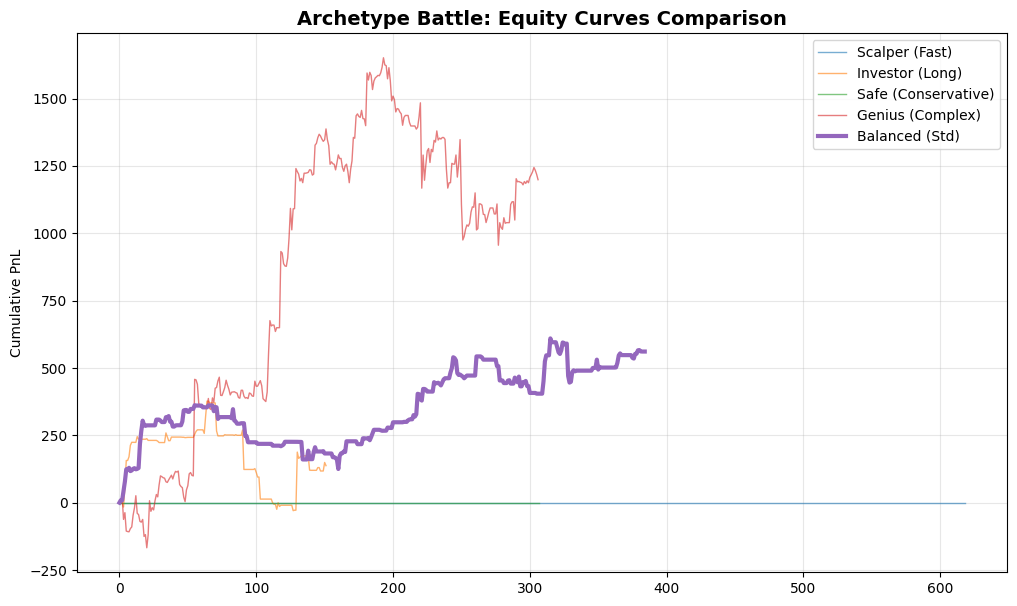


=== 🥇 DETAILED REPORT: BALANCED (STD) ===
Params: W:3500/S:800
------------------------------
Sharpe Ratio:     0.0879
Sortino Ratio:    0.0818
Total PnL:        560.90
Max Drawdown:     -236.62
Win Rate:         53.23%
------------------------------
Skewness: 0.0516
✅ Positive Skewness: Strategia ucina straty, pozwala zyskom rosnąć.
Kurtosis: 13.4404
⚠️ High Kurtosis: 'Fat Tails' - zdarzają się ekstremalne wyniki.


In [29]:
# --- CELL: ARCHETYPE BATTLE WITH DEEP RISK ANALYSIS ---
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm.notebook import tqdm
from scipy.stats import skew, kurtosis

# 1. FUNKCJA LICZĄCA WSZYSTKIE METRYKI (Sharpe, Sortino, Skew, etc.)
def get_full_metrics(equity_curve):
    series = pd.Series(equity_curve)
    returns = series.diff().dropna()
    active_returns = returns[returns != 0]

    # Zabezpieczenie przed pustymi wynikami
    if len(series) < 2: 
        return {k: 0 for k in ['Total PnL', 'Sharpe', 'Sortino', 'Max DD', 'Win Rate', 'Skew', 'Kurtosis']}

    # Podstawowe
    total_pnl = series.iloc[-1] - series.iloc[0]
    
    # Drawdown
    running_max = series.cummax()
    dd = series - running_max
    max_dd = dd.min()

    # Statystyka
    std = returns.std()
    downside_std = returns[returns < 0].std()
    
    sharpe = (returns.mean() / std) if std != 0 else 0
    sortino = (returns.mean() / downside_std) if downside_std != 0 and not np.isnan(downside_std) else 0
    calmar = abs(total_pnl / max_dd) if max_dd != 0 else 0
    
    return {
        'Total PnL': total_pnl,
        'Sharpe': sharpe,
        'Sortino': sortino,
        'Calmar': calmar,
        'Max DD': max_dd,
        'Win Rate': (active_returns > 0).mean() * 100 if len(active_returns) > 0 else 0,
        'Trades': len(active_returns),
        'Skew': returns.skew(),
        'Kurtosis': returns.kurtosis()
    }

def run_archetype_battle_detailed(df):
    print("\n--- ⚔️ BATTLE OF ARCHETYPES: DEEP RISK ANALYSIS ---")
    
    # 2. DEFINICJA ZAWODNIKÓW
    CONFIGS = [
        {'name': 'Scalper (Fast)',      'win': 2000, 'step': 500,  'depth': 4,  'leaf': 100},
        {'name': 'Investor (Long)',     'win': 8000, 'step': 2000, 'depth': 8,  'leaf': 50},
        {'name': 'Safe (Conservative)', 'win': 4000, 'step': 1000, 'depth': 6,  'leaf': 200},
        {'name': 'Genius (Complex)',    'win': 5000, 'step': 1000, 'depth': 12, 'leaf': 20},
        {'name': 'Balanced (Std)',      'win': 3500, 'step': 800,  'depth': 8,  'leaf': 40},
    ]

    results_data = []
    equity_curves = {}
    
    drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
    features = [c for c in df.columns if c not in drop_cols]

    # 3. SYMULACJA
    for cfg in tqdm(CONFIGS, desc="Simulating Strategies"):
        name = cfg['name']
        win, step = cfg['win'], cfg['step']
        depth, leaf = cfg['depth'], cfg['leaf']

        model = RandomForestClassifier(n_estimators=50, max_depth=depth, 
                                       min_samples_leaf=leaf, random_state=42, n_jobs=-1)
        equity = [0]
        
        # Walk-Forward Loop
        for start in range(0, len(df) - win - step, step):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + step].reset_index(drop=True)

            model.fit(train_df[features], train_df['target'])
            probs_test = model.predict_proba(test_df[features])[:, 1]
            
            # Próg 0.51 (Lekka przewaga wystarczy)
            mask = probs_test > 0.51
            pnl_period = test_df.loc[mask, 'pnl'].sum()
            equity.append(equity[-1] + pnl_period)

        # Zapisz krzywą kapitału
        equity_curves[name] = equity
        
        # Oblicz metryki
        stats = get_full_metrics(equity)
        stats['Strategy'] = name
        stats['Params'] = f"W:{win}/S:{step}"
        results_data.append(stats)

    # 4. TABELA WYNIKÓW
    df_res = pd.DataFrame(results_data)
    # Sortujemy po Sharpe Ratio
    df_sorted = df_res.sort_values(by='Sharpe', ascending=False)
    
    print("\n🏆 LEADERBOARD (Sorted by Sharpe):")
    cols = ['Strategy', 'Sharpe', 'Total PnL', 'Max DD', 'Sortino', 'Skew', 'Trades']
    print(df_sorted[cols].to_string(index=False))

    # 5. WYKRES PORÓWNAWCZY
    plt.figure(figsize=(12, 7))
    for name, curve in equity_curves.items():
        # Wyróżnij zwycięzcę grubszą linią
        linewidth = 3 if name == df_sorted.iloc[0]['Strategy'] else 1
        alpha = 1.0 if name == df_sorted.iloc[0]['Strategy'] else 0.6
        plt.plot(curve, label=name, linewidth=linewidth, alpha=alpha)
    
    plt.title('Archetype Battle: Equity Curves Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 6. SZCZEGÓŁOWY RAPORT DLA ZWYCIĘZCY (Z interpretacją)
    winner = df_sorted.iloc[0]
    print(f"\n=== 🥇 DETAILED REPORT: {winner['Strategy'].upper()} ===")
    print(f"Params: {winner['Params']}")
    print("-" * 30)
    print(f"Sharpe Ratio:     {winner['Sharpe']:.4f}")
    print(f"Sortino Ratio:    {winner['Sortino']:.4f}")
    print(f"Total PnL:        {winner['Total PnL']:.2f}")
    print(f"Max Drawdown:     {winner['Max DD']:.2f}")
    print(f"Win Rate:         {winner['Win Rate']:.2f}%")
    print("-" * 30)
    
    # Interpretacja Skewness/Kurtosis (Twoja logika)
    s = winner['Skew']
    k = winner['Kurtosis']
    
    print(f"Skewness: {s:.4f}")
    if s > 0:
        print("✅ Positive Skewness: Strategia ucina straty, pozwala zyskom rosnąć.")
    elif s < -0.5:
        print("⚠️ Negative Skewness: Ryzyko rzadkich, głębokich strat (Black Swan risk).")
    else:
        print("ℹ️ Neutral Skewness: Rozkład symetryczny.")

    print(f"Kurtosis: {k:.4f}")
    if k > 3:
        print("⚠️ High Kurtosis: 'Fat Tails' - zdarzają się ekstremalne wyniki.")
    else:
        print("✅ Low Kurtosis: Stabilne wyniki, brak szaleństw.")
    print("=" * 30)

    # Zwróć parametry zwycięzcy
    best_cfg = next(c for c in CONFIGS if c['name'] == winner['Strategy'])
    return int(best_cfg['win']), int(best_cfg['step']), int(best_cfg['depth']), int(best_cfg['leaf'])

# URUCHOMIENIE
if 'train_val_set' in locals():
    ACADEMIC_WIN, ACADEMIC_STEP, ACADEMIC_DEPTH, ACADEMIC_LEAF = run_archetype_battle_detailed(train_val_set)
else:
    print("Brak danych train_val_set.")

--- 🏁 STARTING FINAL BATTLE ON UNSEEN DATA (20%) 🏁 ---

📡 Testing Logistic Regression (W=5000, S=1000)...
📡 Testing Random Forest (W=3000, S=800)...


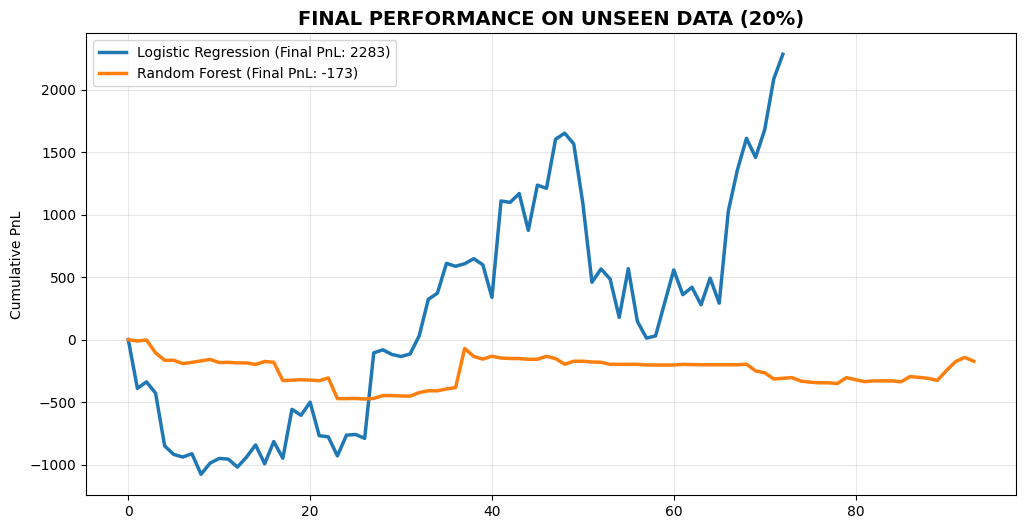

📊 Logistic Regression  | PnL:  2282.50 | Sharpe: 0.1226
📊 Random Forest        | PnL:  -173.01 | Sharpe: -0.0399


In [31]:
# --- CELL: THE ULTIMATE FINAL TEST (UNSEEN DATA 20%) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

def run_unseen_final_battle(test_data):
    print("--- 🏁 STARTING FINAL BATTLE ON UNSEEN DATA (20%) 🏁 ---\n")

    # 1. POBIERANIE NAJLEPSZYCH PARAMETRÓW (Z poprzednich celli lub wartości domyślne)
    # Dla RF bierzemy wyniki z Twojego Academic Pro Search (Cell 32)
    rf_w = locals().get('ACADEMIC_WIN', 3000)
    rf_s = locals().get('ACADEMIC_STEP', 800)
    rf_d = locals().get('ACADEMIC_DEPTH', 8)
    rf_l = locals().get('ACADEMIC_LEAF', 20)

    # Dla LogReg bierzemy stabilne wartości (z Twojego Cella 31)
    lr_w = 5000
    lr_s = 1000

    # 2. KONFIGURACJA MODELI
    LR_CONFIG = {
        'window': lr_w, 'step': lr_s, 'name': 'Logistic Regression',
        'model': LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced', random_state=42),
        'scaler': StandardScaler()
    }

    RF_CONFIG = {
        'window': rf_w, 'step': rf_s, 'name': 'Random Forest',
        'model': RandomForestClassifier(n_estimators=100, max_depth=rf_d, min_samples_leaf=rf_l, random_state=42, n_jobs=-1),
        'scaler': None
    }

    results_pnl = {}

    # 3. SILNIK SYMULACJI (Walk-Forward na danych Unseen)
    for cfg in [LR_CONFIG, RF_CONFIG]:
        print(f"📡 Testing {cfg['name']} (W={cfg['window']}, S={cfg['step']})...")
        df = test_data.copy()
        win, stp, model, scaler = cfg['window'], cfg['step'], cfg['model'], cfg['scaler']

        equity = [0]
        drop_cols = ['entry_idx', 'exit_idx', 'datetime', 'pnl', 'target']
        features = [c for c in df.columns if c not in drop_cols]

        # Pętla po danych testowych
        for start in range(0, len(df) - win - stp, stp):
            train_df = df.iloc[start : start + win]
            test_df = df.iloc[start + win : start + win + stp].reset_index(drop=True)

            X_train, X_test = train_df[features], test_df[features]
            if scaler:
                X_train = scaler.fit_transform(X_train)
                X_test = scaler.transform(X_test)

            model.fit(X_train, train_df['target'])

            # Dynamiczny Threshold
            probs_train = model.predict_proba(X_train)[:, 1]
            best_thr = 0.51
            best_train_pnl = -np.inf
            for thr in np.arange(0.50, 0.61, 0.02):
                mask = probs_train > thr
                if mask.sum() > 5:
                    p = train_df.loc[mask, 'pnl'].sum()
                    if p > best_train_pnl: best_train_pnl = p; best_thr = thr

            # Handel
            probs_test = model.predict_proba(X_test)[:, 1]
            pnl_period = test_df.loc[probs_test > best_thr, 'pnl'].sum()
            equity.append(equity[-1] + pnl_period)

        results_pnl[cfg['name']] = equity

    # --- 4. RAPORT I WYKRES ---
    plt.figure(figsize=(12, 6))
    for name, eq in results_pnl.items():
        plt.plot(eq, label=f"{name} (Final PnL: {eq[-1]:.0f})", linewidth=2.5)

    plt.title('FINAL PERFORMANCE ON UNSEEN DATA (20%)', fontsize=14, fontweight='bold')
    plt.ylabel('Cumulative PnL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Scoreboard
    for name, eq in results_pnl.items():
        ret = pd.Series(eq).diff().dropna()
        sr = (ret.mean() / ret.std()) if ret.std() != 0 else 0
        print(f"📊 {name:<20} | PnL: {eq[-1]:>8.2f} | Sharpe: {sr:.4f}")

# URUCHOMIENIE
if 'final_test_set' in locals():
    run_unseen_final_battle(final_test_set)
else:
    print("❌ BŁĄD: Nie znaleziono 'final_test_set'. Uruchom cell z podziałem danych (80/20)!")